# Análise Exploratória de Dados

Para a análise exploratória de dados vamos utilizar como exemplo a ação da empresa VALE, representada pelo código VALE3. O escopo do modelo são empresas que são impctadas com o valor do dólar, ex: (Commodities, Siderúrgicas, Mineração e petróleo). O modelo pode não informar corretamente uma previsão para empresas que não tem seu valor atrelado ao dólar.

A intenção inicial é descobrir a relação do preço de fechamento da ação com os seguintes indicadores técnicos:
- Média Móvel curta
- Média Móvel intermediária
- Média Móvel Longa
- RSI
- Bandas de Bollinger 

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import mplfinance as mpf

### Recuperação de Dados dos últimos 5 anos

Ao final dessa etapa teremos um único Dataframe com as informações das ações e Dolar 

In [2]:
dat = yf.Ticker("VALE3.SA")
df_vale = dat.history(period='5y')
df_vale = df_vale.reset_index()
df_vale.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-04-30 00:00:00-03:00,67.036621,67.380894,65.846764,65.846764,36888200,0.0,0.0
1,2021-05-03 00:00:00-03:00,66.257473,66.650066,65.387734,65.508530,19641000,0.0,0.0
2,2021-05-04 00:00:00-03:00,65.804490,67.084946,65.629337,66.499077,20775600,0.0,0.0
3,2021-05-05 00:00:00-03:00,67.640604,68.141915,66.674224,66.867500,25990600,0.0,0.0
4,2021-05-06 00:00:00-03:00,67.610398,69.579395,67.332564,69.488800,38194400,0.0,0.0


In [3]:
dat = yf.Ticker("USDBRL=X")
df_dolar = dat.history(period='5y')
df_dolar = df_dolar.reset_index()
df_dolar.rename(columns={"Close":"Dolar"}, inplace=True)
df_dolar.head()

,Date,Open,High,Low,Dolar,Volume,Dividends,Stock Splits
0,2021-05-03 00:00:00+01:00,5.439700,5.4517,5.372536,5.439700,0,0.0,0.0
1,2021-05-04 00:00:00+01:00,5.438200,5.4781,5.431400,5.438100,0,0.0,0.0
2,2021-05-05 00:00:00+01:00,5.443400,5.4443,5.362600,5.442600,0,0.0,0.0
3,2021-05-06 00:00:00+01:00,5.352700,5.3725,5.257100,5.352700,0,0.0,0.0
4,2021-05-07 00:00:00+01:00,5.273467,5.2903,5.203200,5.273431,0,0.0,0.0


In [4]:
#Concatenação dos dataframes de ações e dólar
df_raw_stock_dolar = pd.concat([df_vale, df_dolar["Dolar"]], axis=1)
df_raw_stock_dolar.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Dolar
0,2021-04-30 00:00:00-03:00,67.036621,67.380894,65.846764,65.846764,36888200.0,0.0,0.0,5.439700
1,2021-05-03 00:00:00-03:00,66.257473,66.650066,65.387734,65.508530,19641000.0,0.0,0.0,5.438100
2,2021-05-04 00:00:00-03:00,65.804490,67.084946,65.629337,66.499077,20775600.0,0.0,0.0,5.442600
3,2021-05-05 00:00:00-03:00,67.640604,68.141915,66.674224,66.867500,25990600.0,0.0,0.0,5.352700
4,2021-05-06 00:00:00-03:00,67.610398,69.579395,67.332564,69.488800,38194400.0,0.0,0.0,5.273431


### Saneamento de Dados

In [5]:
# Quantos dados existem agora?

print(f"Quantidade de dados: {len(df_raw_stock_dolar)}")

Quantidade de dados: 1300


In [6]:
#Depdendo da hora de execução, pode ser que tenhamos menos de 60 linhas, pois o mercado fecha às 17h. 
# Se for esse o caso, vamos pegar os dados dos últimos 60 dias, mas só até a data atual.

df_raw_stock_dolar.isna().sum()

Date            52
Open            52
High            52
Low             52
Close           52
Volume          52
Dividends       52
Stock Splits    52
Dolar            0
dtype: int64

In [7]:
# Remove dados faltantes e reseta o índice
df_processed = df_raw_stock_dolar.dropna().reset_index(drop=True)
df_processed.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Dolar
0,2021-04-30 00:00:00-03:00,67.036621,67.380894,65.846764,65.846764,36888200.0,0.0,0.0,5.439700
1,2021-05-03 00:00:00-03:00,66.257473,66.650066,65.387734,65.508530,19641000.0,0.0,0.0,5.438100
2,2021-05-04 00:00:00-03:00,65.804490,67.084946,65.629337,66.499077,20775600.0,0.0,0.0,5.442600
3,2021-05-05 00:00:00-03:00,67.640604,68.141915,66.674224,66.867500,25990600.0,0.0,0.0,5.352700
4,2021-05-06 00:00:00-03:00,67.610398,69.579395,67.332564,69.488800,38194400.0,0.0,0.0,5.273431


In [8]:
#Removendo colunas desnecessárias
df_processed = df_processed.drop(columns=["Dividends", "Stock Splits"])
df_processed.head()

,Date,Open,High,Low,Close,Volume,Dolar
0,2021-04-30 00:00:00-03:00,67.036621,67.380894,65.846764,65.846764,36888200.0,5.439700
1,2021-05-03 00:00:00-03:00,66.257473,66.650066,65.387734,65.508530,19641000.0,5.438100
2,2021-05-04 00:00:00-03:00,65.804490,67.084946,65.629337,66.499077,20775600.0,5.442600
3,2021-05-05 00:00:00-03:00,67.640604,68.141915,66.674224,66.867500,25990600.0,5.352700
4,2021-05-06 00:00:00-03:00,67.610398,69.579395,67.332564,69.488800,38194400.0,5.273431


In [9]:
# Quantos dados existem agora?

print(f"Quantidade de dados: {len(df_processed)}")

Quantidade de dados: 1248


### Criação de indicadores

In [10]:
#Criando médias móveis
df_feature = df_processed.copy()
df_feature["short_mm"] = df_feature["Close"].rolling(5, min_periods=1).mean()
df_feature["medium_mm"] = df_feature["Close"].rolling(15, min_periods=1).mean()
df_feature["large_mm"] = df_feature["Close"].rolling(45, min_periods=1).mean()

In [11]:
 # RSI (14 períodos)
df_feature["Delta"] = df_feature["Close"].diff()
df_feature["Gain"]  = df_feature["Delta"].clip(lower=0).rolling(14, min_periods=1).mean()
df_feature["Loss"] = (-df_feature["Delta"].clip(upper=0)).rolling(14, min_periods=1).mean()
df_feature["RS"] = df_feature["Gain"] / df_feature["Loss"]
df_feature["RSI"] = (100 - (100 / (1 + df_feature["RS"])))
df_feature = df_feature.drop(columns=["Gain", "Loss", "RS"])


In [12]:
# Bandas de Bollinger (20 períodos)
df_feature["ma20"]       = df_feature["Close"].rolling(20, min_periods=1).mean()
df_feature["std20"]      = df_feature["Close"].rolling(20, min_periods=1).std()
df_feature["bb_upper_band"] = (df_feature["ma20"] + 2 * df_feature["std20"])
df_feature["bb_lower_band"] = (df_feature["ma20"] - 2 * df_feature["std20"])
df_feature = df_feature.drop(columns=["ma20", "std20"])
df_feature.dropna(inplace=True)

In [13]:
#Como ficou o dataframe final?
df_final = df_feature.copy()
df_final.head()

,Date,Open,High,Low,Close,Volume,Dolar,short_mm,medium_mm,large_mm,Delta,RSI,bb_upper_band,bb_lower_band
1,2021-05-03 00:00:00-03:00,66.257473,66.650066,65.387734,65.508530,19641000.0,5.438100,65.677647,65.677647,65.677647,-0.338234,0.000000,66.155982,65.199312
2,2021-05-04 00:00:00-03:00,65.804490,67.084946,65.629337,66.499077,20775600.0,5.442600,65.951457,65.951457,65.951457,0.990547,74.545548,66.958465,64.944448
3,2021-05-05 00:00:00-03:00,67.640604,68.141915,66.674224,66.867500,25990600.0,5.352700,66.180468,66.180468,66.180468,0.368423,80.071115,67.411394,64.949541
4,2021-05-06 00:00:00-03:00,67.610398,69.579395,67.332564,69.488800,38194400.0,5.273431,66.842134,66.842134,66.842134,2.621300,92.167799,69.987358,63.696910
5,2021-05-07 00:00:00-03:00,70.388757,70.394798,68.969386,69.730408,21678700.0,5.235500,67.618863,67.323513,67.323513,0.241608,92.582771,70.994394,63.652632


### Preparação final para Comparação Gráfica de Comparação

In [14]:
# Somente ajustando o índice para a data, para facilitar a visualização dos candles
df_final["Date"] = pd.to_datetime(df_final["Date"])
df_final = df_final.set_index("Date").sort_index()

In [15]:
# Quantos dados existem agora?
len(df_feature)

1247

In [16]:
#Adicionando estilo ao mapa
estilo = mpf.make_mpf_style(
    base_mpf_style="nightclouds",
    marketcolors=mpf.make_marketcolors(
        up="#26a69a",     # verde para alta
        down="#ef5350",   # vermelho para baixa
        edge="inherit",
        wick="inherit",
        volume="in",
    ),
    facecolor="#1e1e2e",
    figcolor="#1e1e2e",
    gridcolor="#2a2a3e",
    gridstyle="--",
    y_on_right=True,
)

In [17]:
#Pegar os ultimos 60 dias para visualização no gráfico
df_grafico = df_final.copy()
df_grafico = df_grafico[-60:]
df_grafico.head()

,Open,High,Low,Close,Volume,Dolar,short_mm,medium_mm,large_mm,Delta,RSI,bb_upper_band,bb_lower_band
Date,,,,,,,,,,,,,
2026-02-02 00:00:00-03:00,84.419998,85.849998,84.040001,84.820000,22289400.0,5.3868,85.684001,82.176000,73.942549,0.500000,73.313644,89.045232,71.941769
2026-02-03 00:00:00-03:00,86.419998,89.000000,86.419998,88.989998,37709700.0,5.3794,86.502000,83.085333,74.514152,4.169998,74.079392,90.205868,72.093132
2026-02-04 00:00:00-03:00,88.510002,89.589996,87.550003,89.430000,51744400.0,5.3308,86.994000,83.786000,75.100812,0.440002,74.859028,91.277770,72.332229
2026-02-05 00:00:00-03:00,87.989998,88.930000,86.239998,86.449997,57049000.0,5.3554,86.801999,84.292667,75.598655,-2.980003,65.621128,91.561204,73.135795
2026-02-06 00:00:00-03:00,86.410004,87.559998,85.199997,85.629997,28889600.0,5.3354,87.063998,84.742667,76.067295,-0.820000,64.268383,91.475178,74.312821


### Gráficos

##### OLHC (Open, Low, High and Close)

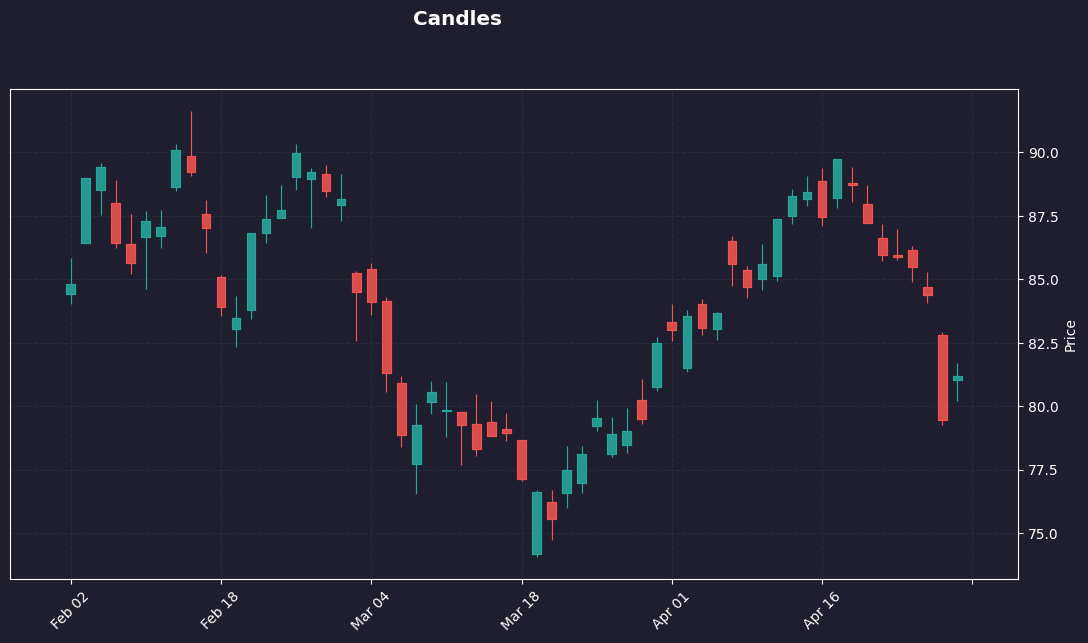

In [18]:

mpf.plot(df_grafico, type="candle", style=estilo, title="Candles", figsize=(14, 7))

##### OLHC x Volume

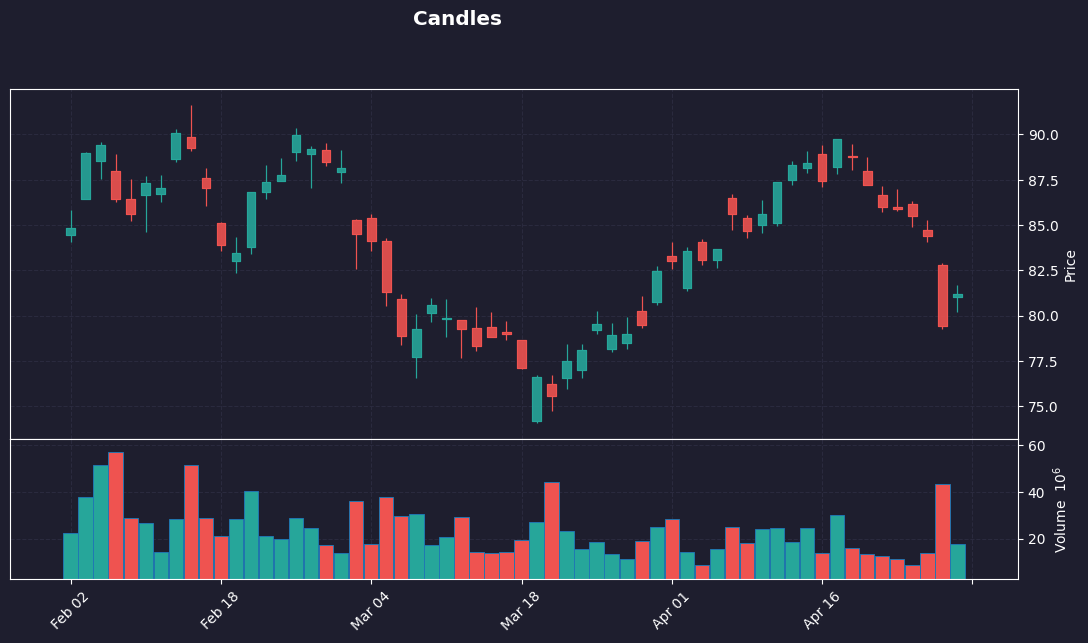

In [19]:
mpf.plot(df_grafico, type="candle", style=estilo,volume=True, title="Candles", figsize=(14, 7))

##### No gráfico acima, podemos perceber que quando o volume se destaca, existe uma movimentação contrária no preço.


##### OLHC x Dolar

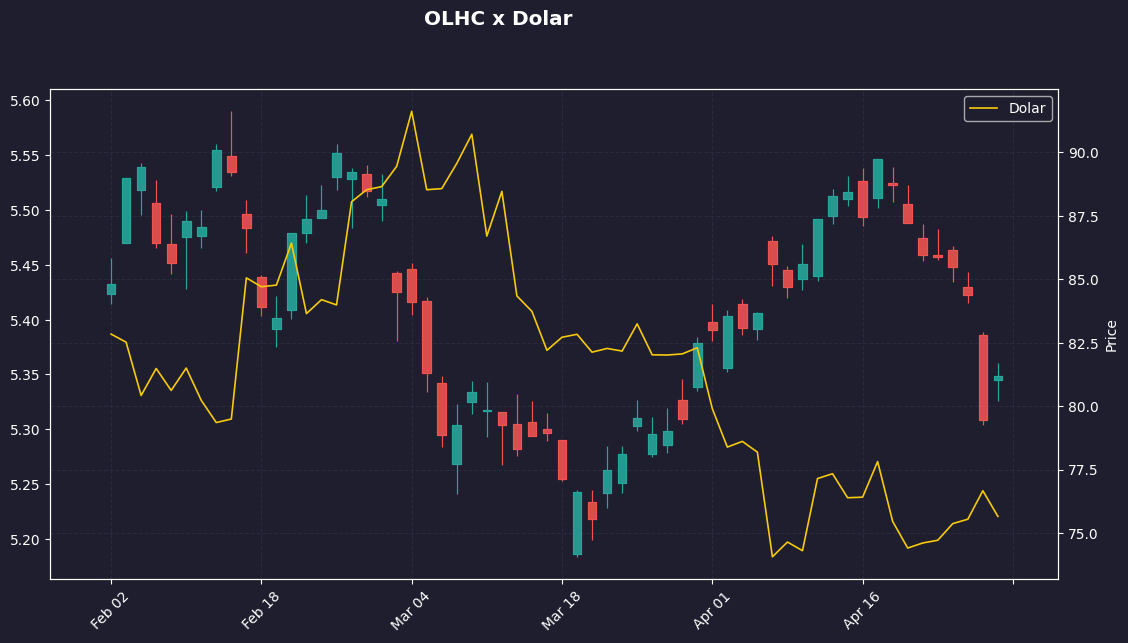

In [20]:
dolar = [
    mpf.make_addplot(df_grafico["Dolar"],  color="#f6c90e", width=1.2, label="Dolar"),
]

mpf.plot(df_grafico, type="candle", style=estilo, addplot=dolar, title="OLHC x Dolar", figsize=(14, 7))

#### Nos primeiros 45 dias, aparentemente o Dólar tem alguma relação com o valor da ação. A partir do dia 45 parece não fazer tanto sentido mais. Talvez algum evento em particular.

##### OLHC x Médias Móveis

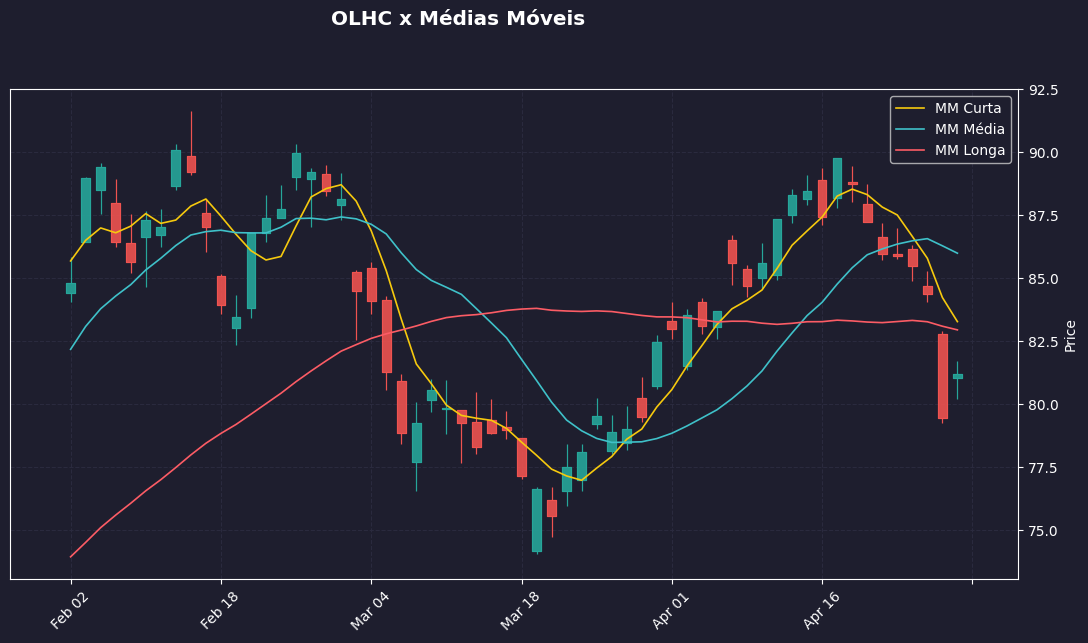

In [21]:
medias = [
    mpf.make_addplot(df_grafico["short_mm"],  color="#f6c90e", width=1.2, label="MM Curta"),
    mpf.make_addplot(df_grafico["medium_mm"], color="#3fc1c9", width=1.2, label="MM Média"),
    mpf.make_addplot(df_grafico["large_mm"],  color="#fc5c65", width=1.2, label="MM Longa"),
]

mpf.plot(df_grafico, type="candle", style=estilo, addplot=medias, title="OLHC x Médias Móveis", figsize=(14, 7))

#### As médias móveis parecem ter uma certa relação. Principalmente no cruzamento das médias móveis curta e média

### OLHC x RSI

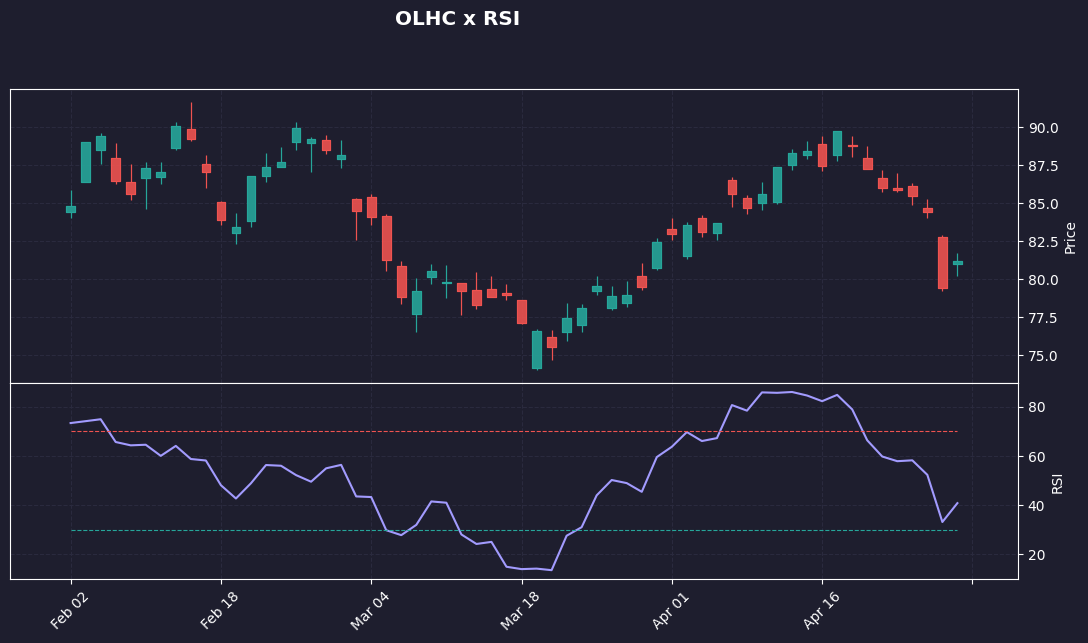

In [22]:
# Linhas horizontais de referência do RSI (70 e 30)
rsi_upper = pd.Series(70, index=df_grafico.index)
rsi_lower = pd.Series(30, index=df_grafico.index)
extras = [
    # RSI no painel 2
    mpf.make_addplot(df_grafico["RSI"],color="#a29bfe", width=1.5, panel=1, ylabel="RSI"),

    # Linhas de referência 70 e 30
    mpf.make_addplot(rsi_upper, color="#ef5350", width=0.8, linestyle="--", panel=1),
    mpf.make_addplot(rsi_lower, color="#26a69a", width=0.8, linestyle="--", panel=1),
]

mpf.plot(df_grafico, type="candle", style=estilo,  addplot=extras, panel_ratios=(3, 2),title="OLHC x RSI", figsize=(14, 7))

#### Aqui podemos ver que existe uma certa coerência nos cruzamentos de linha nas bases de cima e abaixo do RSI, onde vemos que a direção do mercado se altera com base nesses cruzamentos.

#### OLHC x Bandas de Bollinger

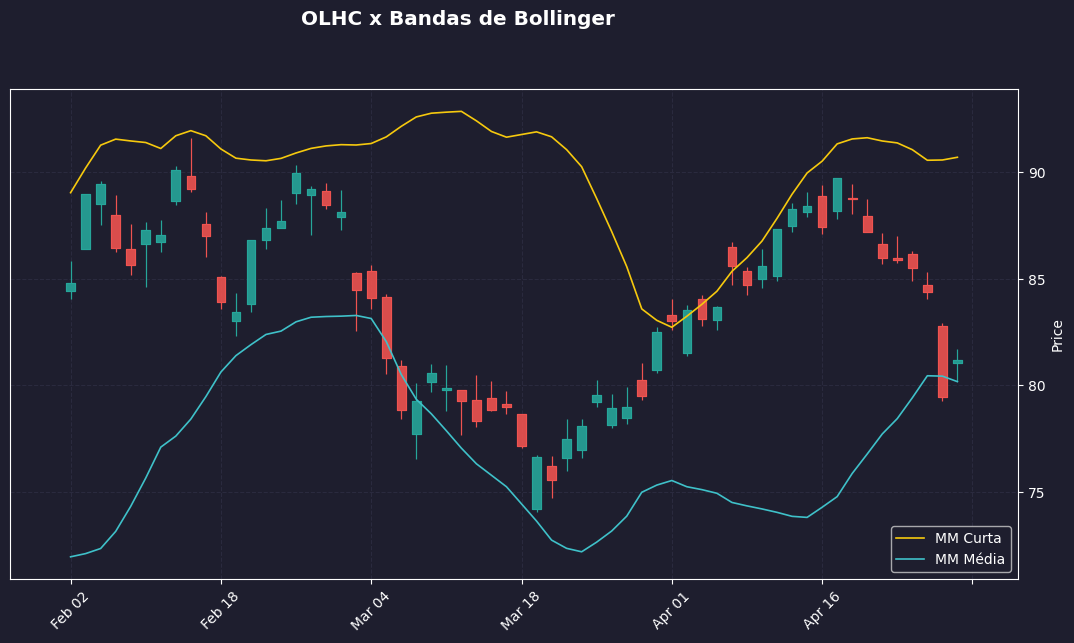

In [23]:
bb = [
    mpf.make_addplot(df_grafico["bb_upper_band"],  color="#f6c90e", width=1.2, label="MM Curta"),
    mpf.make_addplot(df_grafico["bb_lower_band"], color="#3fc1c9", width=1.2, label="MM Média"),
]

mpf.plot(df_grafico, type="candle", style=estilo, addplot=bb, title="OLHC x Bandas de Bollinger", figsize=(14, 7))

#### Aqui podemos ver que os preços sobem e descem de acordo com os limites da banda de bollinger na maioria dos casos

### Conclusão:

#### De acordo com os gráficos acima, podemos ver que os indicadores escolhidos fazem sentido para o desenvolvimetno do modelo atual.